# Recursive Spectral Modularity Partitioning — Karate Club

## Assignment objective
This notebook implements **recursive spectral modularity partitioning** on the Zachary Karate Club graph.

It provides:
- recursive community detection using the leading eigenvector of a **restricted modularity matrix**;
- graph visualizations after every accepted split;
- degree centrality, betweenness centrality, closeness centrality, and clustering coefficient;
- metric evolution within the induced current communities;
- modularity \(Q\) and modularity gain \(\Delta Q\) for every iteration; and
- a short discussion of central nodes and the effect of community structure.

### Important implementation choice
The Karate Club graph is treated as an **unweighted graph**, matching the assignment setup. The graph distributed by NetworkX contains an edge attribute named `weight`; this notebook explicitly ignores that attribute when building the adjacency matrix and when computing the centrality measures.

### Spectral modularity method
For the whole graph,

\[
B_{ij}=A_{ij}-\frac{k_i k_j}{2m}.
\]

For a current community \(C\), the restricted modularity matrix is

\[
B^{(C)}_{ij}
=
B_{ij}
-
\delta_{ij}\sum_{\ell\in C}B_{i\ell},
\qquad i,j\in C.
\]

The leading eigenvector of \(B^{(C)}\) gives a candidate bipartition from the signs of its entries. The split is accepted only when the **actual modularity gain**

\[
\Delta Q=\frac{1}{4m}s^T B^{(C)}s
\]

is positive. The procedure is then applied recursively to the resulting communities.


In [1]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

SEED = 42
TOL = 1e-10

# Zachary Karate Club graph
G = nx.karate_club_graph()
nodes = list(G.nodes())
n = G.number_of_nodes()
m = G.number_of_edges()

# Explicitly use an UNWEIGHTED adjacency matrix.
# NetworkX's Karate Club graph has a "weight" edge attribute, but the
# assignment is treated as an unweighted social network.
A = nx.to_numpy_array(G, nodelist=nodes, dtype=float, weight=None)
degrees = A.sum(axis=1)

# Fixed layout so every iteration is directly comparable.
pos = nx.spring_layout(G, seed=SEED)

print(f"Karate Club graph: {n} nodes, {m} edges")
print(f"Sum of degrees = {degrees.sum():.0f} = 2m = {2*m}")


Karate Club graph: 34 nodes, 78 edges
Sum of degrees = 156 = 2m = 156


## 1. Modularity matrix

The modularity matrix compares observed connections with the number expected under the degree-preserving null model:

\[
B=A-\frac{kk^T}{2m}.
\]

A positive leading eigenvalue indicates a direction in which the modularity can potentially be increased by a bipartition.


In [2]:
# Whole-graph modularity matrix
B = A - np.outer(degrees, degrees) / (2.0 * m)

print("B shape:", B.shape)
print("Maximum absolute row-sum error (should be ~0):",
      np.abs(B.sum(axis=1)).max())


B shape: (34, 34)
Maximum absolute row-sum error (should be ~0): 8.881784197001252e-16


## 2. Restricted modularity matrix for recursive splitting

When a community \(C\) is split, we do **not** simply take a submatrix of the original \(B\). We use the restricted matrix

\[
B^{(C)}_{ij}
=
B_{ij}
-
\delta_{ij}\sum_{\ell\in C}B_{i\ell}.
\]

This correction is essential for recursive Newman-style spectral modularity partitioning.


In [3]:
node_to_index = {node: i for i, node in enumerate(nodes)}

def restricted_modularity_matrix(community):
    """Return the restricted modularity matrix B^(C) for community C."""
    community = list(community)
    idx = [node_to_index[v] for v in community]

    B_sub = B[np.ix_(idx, idx)].copy()
    row_sums = B_sub.sum(axis=1)

    # B^(C) = B_sub - diag(row_sums)
    return B_sub - np.diag(row_sums)


def candidate_split(community):
    """Find the leading-eigenvector bipartition and its actual ΔQ."""
    community = list(community)
    if len(community) <= 1:
        return None

    B_C = restricted_modularity_matrix(community)
    eigenvalues, eigenvectors = np.linalg.eigh(B_C)

    lambda_max = float(eigenvalues[-1])
    leading_vector = eigenvectors[:, -1]

    # Bipartition by the sign of the leading eigenvector.
    left = [community[i] for i, value in enumerate(leading_vector) if value >= 0]
    right = [community[i] for i, value in enumerate(leading_vector) if value < 0]

    if not left or not right:
        return None

    s = np.where(leading_vector >= 0, 1.0, -1.0)

    # Actual modularity gain of this sign partition.
    delta_q = float((s @ B_C @ s) / (4.0 * m))

    # Accept only positive-gain splits.
    if delta_q <= TOL:
        return None

    return {
        "community": community,
        "lambda_max": lambda_max,
        "leading_vector": leading_vector,
        "left": left,
        "right": right,
        "delta_q": delta_q,
    }


def partition_modularity(partition):
    """Global modularity Q of a partition of the original unweighted graph."""
    return float(nx.community.modularity(G, partition, weight=None))


## 3. Recursive spectral modularity partitioning

At each iteration, every currently active community is tested.

- If a community has a positive-gain spectral split, it is divided into two.
- Otherwise it remains unchanged.
- The process stops when no active community has a positive-gain split.

The global modularity is recomputed directly after every accepted round as a numerical check.


In [4]:
def recursive_spectral_modularity():
    current = [nodes.copy()]

    history = [{
        "iteration": 0,
        "partition": [c.copy() for c in current],
        "accepted_splits": [],
        "modularity": partition_modularity(current),
        "delta_q_total": 0.0
    }]

    iteration = 0

    while True:
        iteration += 1
        next_partition = []
        accepted_splits = []

        for community in current:
            result = candidate_split(community)

            if result is None:
                next_partition.append(community)
            else:
                next_partition.extend([result["left"], result["right"]])
                accepted_splits.append(result)

        if not accepted_splits:
            break

        current = next_partition
        total_delta_q = sum(r["delta_q"] for r in accepted_splits)
        Q = partition_modularity(current)

        history.append({
            "iteration": iteration,
            "partition": [c.copy() for c in current],
            "accepted_splits": accepted_splits,
            "modularity": Q,
            "delta_q_total": total_delta_q
        })

    return history


history = recursive_spectral_modularity()

summary_rows = []
for record in history:
    summary_rows.append({
        "Iteration": record["iteration"],
        "Communities": len(record["partition"]),
        "Accepted splits": len(record["accepted_splits"]),
        "Total ΔQ": record["delta_q_total"],
        "Global Q": record["modularity"]
    })

modularity_df = pd.DataFrame(summary_rows)

print(f"Accepted split rounds: {len(history)-1}")
print(f"Final number of communities: {len(history[-1]['partition'])}")
display(modularity_df.round(6))


Accepted split rounds: 2
Final number of communities: 4


,Iteration,Communities,Accepted splits,Total ΔQ,Global Q
0,0,1,0,0.000000,0.000000
1,1,2,1,0.371466,0.371466
2,2,4,2,0.021943,0.393409


In [5]:
# Details of every accepted spectral split
split_rows = []

for record in history[1:]:
    for split_number, result in enumerate(record["accepted_splits"], start=1):
        split_rows.append({
            "Iteration": record["iteration"],
            "Split": split_number,
            "Parent size": len(result["community"]),
            "Child sizes": f"{len(result['left'])} + {len(result['right'])}",
            "Leading eigenvalue": result["lambda_max"],
            "ΔQ": result["delta_q"]
        })

split_df = pd.DataFrame(split_rows)
display(split_df.round(6))


,Iteration,Split,Parent size,Child sizes,Leading eigenvalue,ΔQ
0,1,1,34,16 + 18,4.977080,0.371466
1,2,1,16,7 + 9,1.178538,0.001233
2,2,2,18,12 + 6,0.859415,0.020710


## 4. Visualize the graph after every split

The node positions are kept fixed across all iterations, so the colors—not the layout—show how the community assignment changes.


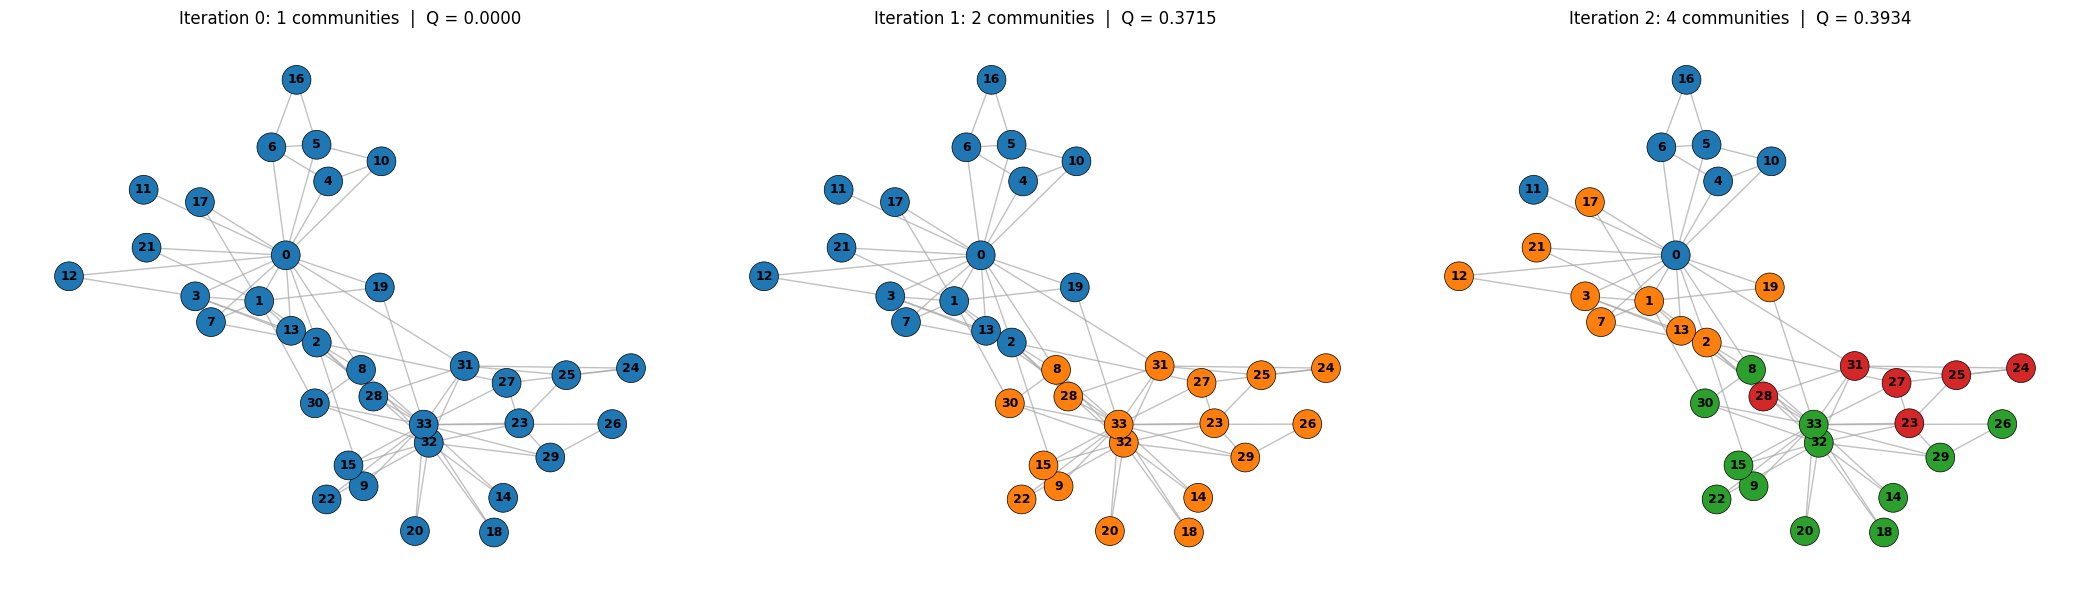

In [6]:
def draw_partition(partition, iteration, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(9, 6))

    cmap = plt.get_cmap("tab10")
    node_to_color = {}

    for cid, community in enumerate(partition):
        for node in community:
            node_to_color[node] = cmap(cid % 10)

    nx.draw_networkx_edges(
        G, pos, ax=ax,
        edge_color="0.65", width=1.0, alpha=0.7
    )
    nx.draw_networkx_nodes(
        G, pos, ax=ax,
        nodelist=nodes,
        node_color=[node_to_color[v] for v in nodes],
        node_size=430,
        edgecolors="black",
        linewidths=0.5
    )
    nx.draw_networkx_labels(
        G, pos, ax=ax,
        font_size=9,
        font_weight="bold"
    )

    ax.set_axis_off()
    Q = partition_modularity(partition)
    ax.set_title(
        f"Iteration {iteration}: {len(partition)} communities  |  Q = {Q:.4f}"
    )


fig, axes = plt.subplots(1, len(history), figsize=(7 * len(history), 6))
if len(history) == 1:
    axes = [axes]

for ax, record in zip(axes, history):
    draw_partition(record["partition"], record["iteration"], ax=ax)

plt.tight_layout()
plt.show()


## 5. Node metrics

The Karate Club graph itself is unchanged by community labeling. Therefore, recalculating centrality on the full original graph at every iteration would simply reproduce the same values.

For the required **evolution** analysis, this notebook instead calculates each metric on the **induced subgraph of the node's current community** at each iteration. This answers:

> How central is each node within its own community as the recursive partition becomes finer?

The four requested metrics are:
- Degree centrality
- Betweenness centrality
- Closeness centrality
- Clustering coefficient


In [7]:
def local_metrics_for_partition(partition):
    result = {
        "degree": {v: np.nan for v in nodes},
        "betweenness": {v: np.nan for v in nodes},
        "closeness": {v: np.nan for v in nodes},
        "clustering": {v: np.nan for v in nodes},
        "community": {}
    }

    for cid, community in enumerate(partition, start=1):
        # G is unweighted, so the induced subgraph is also unweighted.
        H = G.subgraph(community).copy()

        degree = nx.degree_centrality(H)
        betweenness = nx.betweenness_centrality(H, normalized=True)
        closeness = nx.closeness_centrality(H)
        clustering = nx.clustering(H)

        for v in community:
            result["degree"][v] = degree[v]
            result["betweenness"][v] = betweenness[v]
            result["closeness"][v] = closeness[v]
            result["clustering"][v] = clustering[v]
            result["community"][v] = cid

    return result


metric_history = [
    local_metrics_for_partition(record["partition"])
    for record in history
]

metric_names = ["degree", "betweenness", "closeness", "clustering"]

metric_rows = []
for iteration, metric_dict in enumerate(metric_history):
    for node in nodes:
        metric_rows.append({
            "Iteration": iteration,
            "Node": node,
            "Community": metric_dict["community"][node],
            **{
                metric: metric_dict[metric][node]
                for metric in metric_names
            }
        })

metrics_df = pd.DataFrame(metric_rows)

display(metrics_df.head(12).round(4))


,Iteration,Node,Community,degree,betweenness,closeness,clustering
0,0,0,1,0.4848,0.4376,0.5690,0.1500
1,0,1,1,0.2727,0.0539,0.4853,0.3333
2,0,2,1,0.3030,0.1437,0.5593,0.2444
3,0,3,1,0.1818,0.0119,0.4648,0.6667
4,0,4,1,0.0909,0.0006,0.3793,0.6667
5,0,5,1,0.1212,0.0300,0.3837,0.5000
6,0,6,1,0.1212,0.0300,0.3837,0.5000
7,0,7,1,0.1212,0.0000,0.4400,1.0000
8,0,8,1,0.1515,0.0559,0.5156,0.5000
9,0,9,1,0.0606,0.0008,0.4342,0.0000


### Global centrality baseline

The following table gives the requested metrics on the **original unweighted Karate Club graph**. It is useful for discussing which nodes are globally central.


In [8]:
global_degree = nx.degree_centrality(G)
global_betweenness = nx.betweenness_centrality(G, normalized=True)
global_closeness = nx.closeness_centrality(G)
global_clustering = nx.clustering(G)

global_metrics = pd.DataFrame({
    "Degree": pd.Series(global_degree),
    "Betweenness": pd.Series(global_betweenness),
    "Closeness": pd.Series(global_closeness),
    "Clustering": pd.Series(global_clustering)
}).sort_index()

top_rows = []
for metric in global_metrics.columns:
    for rank, (node, value) in enumerate(
        global_metrics[metric].sort_values(ascending=False).head(5).items(),
        start=1
    ):
        top_rows.append({
            "Metric": metric,
            "Rank": rank,
            "Node": node,
            "Value": value
        })

top_global_df = pd.DataFrame(top_rows)
display(top_global_df.round(4))


,Metric,Rank,Node,Value
0,Degree,1,33,0.5152
1,Degree,2,0,0.4848
2,Degree,3,32,0.3636
3,Degree,4,2,0.3030
4,Degree,5,1,0.2727
5,Betweenness,1,0,0.4376
6,Betweenness,2,33,0.3041
7,Betweenness,3,32,0.1452
8,Betweenness,4,2,0.1437
9,Betweenness,5,31,0.1383


## 6. Plot metric evolution across iterations

Nodes 0 and 33 are highlighted for readability. The remaining node trajectories are still shown faintly so the complete network is represented.


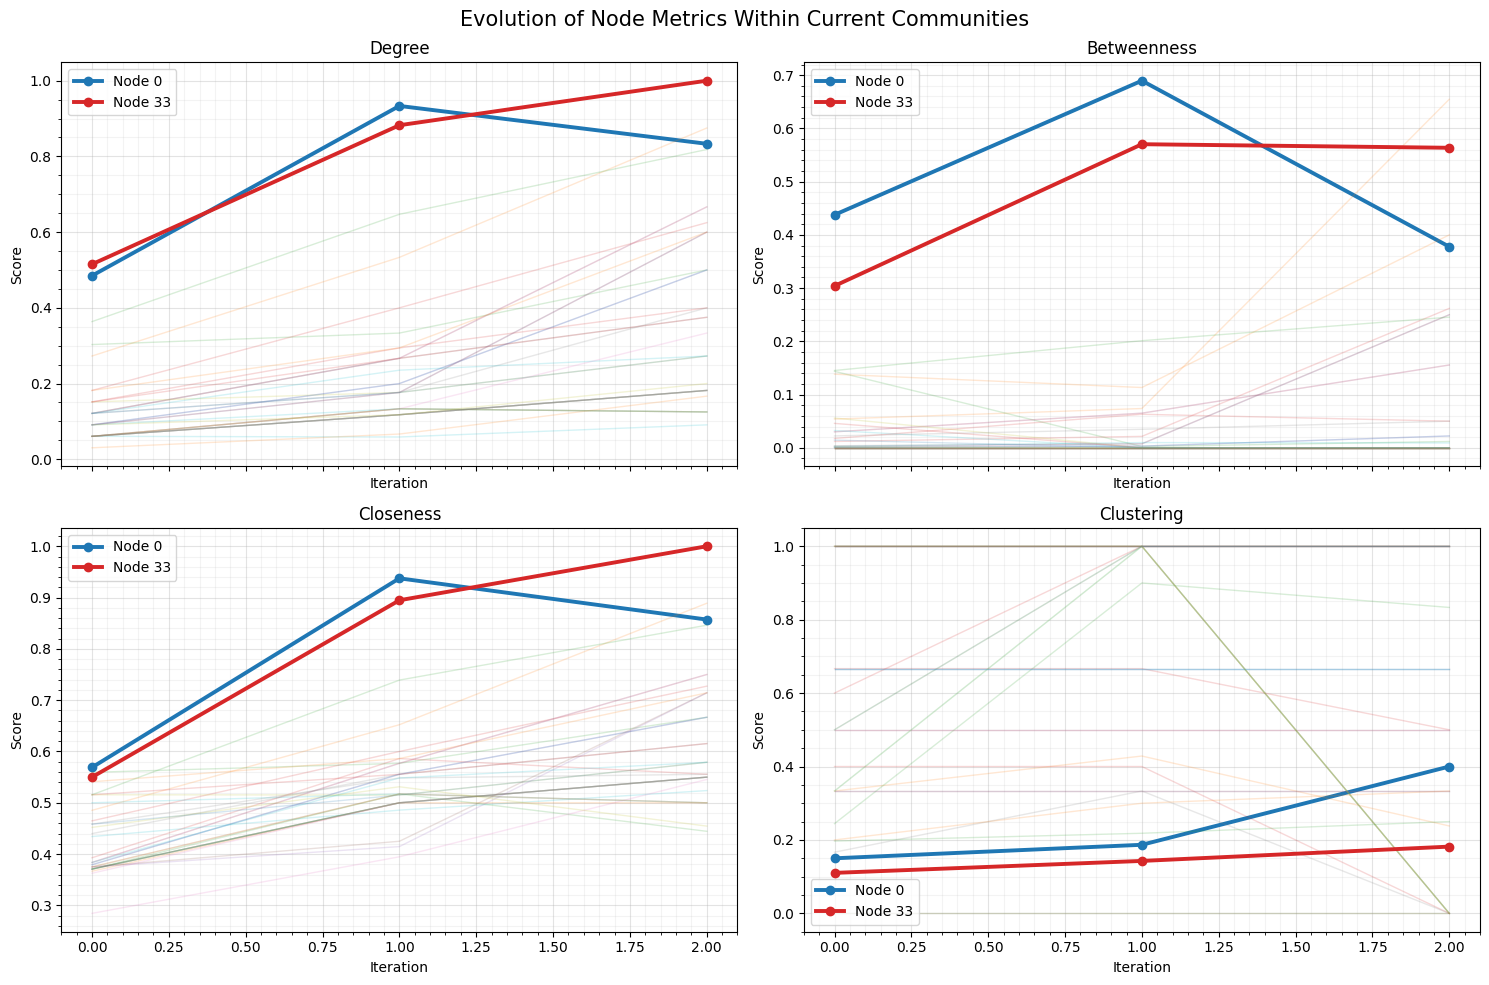

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10), sharex=True)
axes = axes.flatten()
x = list(range(len(history)))

for ax, metric in zip(axes, metric_names):
    for node in nodes:
        values = [
            metric_dict[metric][node]
            for metric_dict in metric_history
        ]

        if node == 0:
            ax.plot(x, values, linewidth=2.8, marker="o", label="Node 0")
        elif node == 33:
            ax.plot(x, values, linewidth=2.8, marker="o", label="Node 33")
        else:
            ax.plot(x, values, alpha=0.18, linewidth=1)

    ax.set_title(metric.capitalize())
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Score")
    ax.grid(True, which="major", alpha=0.35)
    ax.grid(True, which="minor", alpha=0.15)
    ax.minorticks_on()
    ax.legend()

fig.suptitle(
    "Evolution of Node Metrics Within Current Communities",
    fontsize=15
)
plt.tight_layout()
plt.show()


## 7. Modularity evolution

This is the objective used to decide whether recursive splits are accepted.


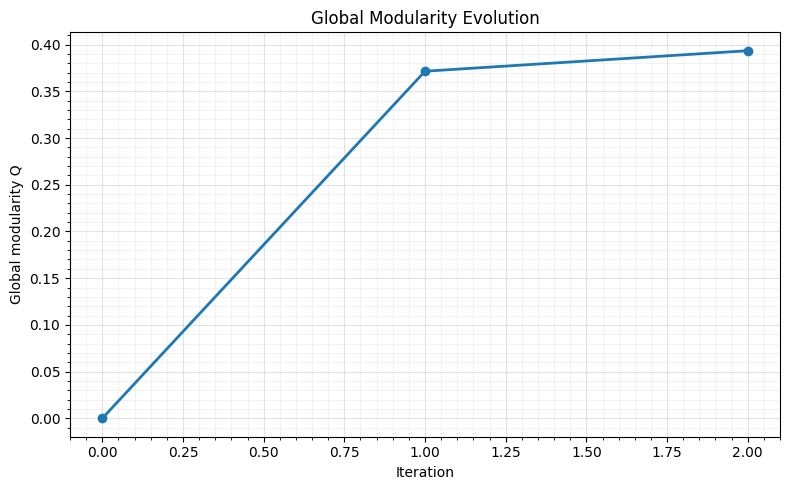

In [10]:
plt.figure(figsize=(8, 5))
plt.plot(
    modularity_df["Iteration"],
    modularity_df["Global Q"],
    marker="o",
    linewidth=2
)
plt.xlabel("Iteration")
plt.ylabel("Global modularity Q")
plt.title("Global Modularity Evolution")
plt.grid(True, which="major", alpha=0.35)
plt.grid(True, which="minor", alpha=0.15)
plt.minorticks_on()
plt.tight_layout()
plt.show()


## 8. Final community membership


In [11]:
final_partition = history[-1]["partition"]

community_rows = []
for cid, community in enumerate(final_partition, start=1):
    community_rows.append({
        "Community": cid,
        "Nodes": ", ".join(map(str, sorted(community))),
        "Size": len(community)
    })

final_communities_df = pd.DataFrame(community_rows)
display(final_communities_df)


,Community,Nodes,Size
0,1,"0, 4, 5, 6, 10, 11, 16",7
1,2,"1, 2, 3, 7, 12, 13, 17, 19, 21",9
2,3,"8, 9, 14, 15, 18, 20, 22, 26, 29, 30, 32, 33",12
3,4,"23, 24, 25, 27, 28, 31",6


## 9. Discussion

The recursive spectral procedure starts with the full Karate Club network and accepts a split only when the proposed eigenvector partition gives a positive modularity gain. Thus the number of communities increases only while the detected division improves the modularity objective.

In the original graph, the highest degree centrality is associated with nodes 33 and 0, while node 0 has the highest betweenness and closeness among the nodes in this unweighted representation. Node 33 also has high betweenness and closeness. These results show that a node can be central because it has many direct links, because it lies on many shortest paths, or because it is close to many other nodes.

Community structure changes the interpretation of these metrics. When centrality is recomputed inside the induced community subgraphs, nodes that connect different groups can lose local betweenness because cross-community shortest paths are no longer available. Local degree and closeness can also change when a node's neighbors lie in other communities. Clustering can remain high for nodes embedded in tightly connected local neighborhoods.

Therefore, global and local centrality answer different questions. A node may be highly central in the full social network but less central inside a smaller final community. Conversely, a node with fewer global connections can become relatively central within its own densely connected community.

For this graph, the final partition separates the network into four communities, and the reported modularity increases from 0 at iteration 0 to the final value shown in the modularity table. The modularity table and modularity-evolution plot provide the quantitative evidence for the accepted recursive splits. The final metric table shows how the local structure of those communities changes the apparent importance of individual nodes.

> **Note:** the exact community labels are arbitrary; swapping the names of two communities does not change the partition.


## 10. Conclusion

This notebook implements the assignment's **recursive spectral modularity partitioning** directly rather than replacing it with a generic scikit-learn spectral-clustering call.

The workflow is

\[
\text{Karate Club graph}
\rightarrow
B^{(C)}
\rightarrow
\text{leading eigenvector}
\rightarrow
\text{sign split}
\rightarrow
\Delta Q
\rightarrow
\text{recursive split}.
\]

It produces the required community visualizations, node metrics, metric-evolution plots, modularity results, final community membership, and discussion.
